<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/GFP_Intensity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Setup Environment
Import the necessary libraries for data handling and analysis.

In [12]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data
df = pd.read_csv('GFP_raw_sum_normalized.csv')
# Keep only HF and NF for analysis
df_gfp = df[df['Variant'].isin(['HF', 'NF'])].copy()
print("Data loaded successfully.")

Data loaded successfully.


# Block 2.5: Outlier Removal
Remove outliers using the 1.5 IQR method to ensure robust statistical analysis and visualization. This step is performed after initial data loading and filtering.

In [13]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'Intensity_per_µm2'
Q1 = df_gfp['Intensity_per_µm2'].quantile(0.25)
Q3 = df_gfp['Intensity_per_µm2'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_gfp_cleaned = df_gfp[(df_gfp['Intensity_per_µm2'] >= lower_bound) & (df_gfp['Intensity_per_µm2'] <= upper_bound)]

print(f"Original number of data points: {len(df_gfp)}")
print(f"Number of data points after outlier removal: {len(df_gfp_cleaned)}")

# Update df_gfp to the cleaned version for subsequent analysis
df_gfp = df_gfp_cleaned.copy()

print("Outliers removed and df_gfp updated.")

Original number of data points: 21
Number of data points after outlier removal: 21
Outliers removed and df_gfp updated.


# Block 2: Normality Check
It is standard practice to check if your data is normally distributed before choosing a statistical test.

In [14]:
hf_data = df_gfp[df_gfp['Variant'] == 'HF']['Intensity_per_µm2']
nf_data = df_gfp[df_gfp['Variant'] == 'NF']['Intensity_per_µm2']

# Shapiro-Wilk test
stat_hf, p_hf = stats.shapiro(hf_data)
stat_nf, p_nf = stats.shapiro(nf_data)

print(f"Normality Test - HF: p={p_hf:.4f}, NF: p={p_nf:.4f}")

Normality Test - HF: p=0.9369, NF: p=0.0738


# Block 3: Statistical Test
Based on the normality result, we Auto-select the appropriate test.

In [15]:
# Select test: T-test if normal (p > 0.05), Mann-Whitney if not (p < 0.05)
if p_hf < 0.05 or p_nf < 0.05:
    test_type = "Mann-Whitney U"
    stat, p_val = stats.mannwhitneyu(hf_data, nf_data)
else:
    test_type = "Independent T-test"
    stat, p_val = stats.ttest_ind(hf_data, nf_data)

print(f"Test used: {test_type}")
print(f"p-value: {p_val:.4e}")

Test used: Independent T-test
p-value: 1.1467e-08


# Block 4: Global Plot Styling
This defines the aesthetic the plots to ensure consistency.

In [22]:
# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 25,      # Global title padding
    "axes.labelsize": 12,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2
})

# --- GLOBAL ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}
global_fig_size = (6, 6)
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6 # Used for boxplot and stripplot fill transparency
global_box_width = 0.4
global_asterisk_size = 18
global_asterisk_weight = 'bold'
global_jitter_edgecolor = 'black' # New global setting for jitter outline color
global_jitter_linewidth = 1     # New global setting for jitter outline width
global_y_nbins = 3

print("Styles initialized.")

Styles initialized.


# Block 5: Create Plot & Save as SVG
This generates the high-resolution vector graphic

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2931/3505261502.py:22: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Intensity (arbitrary units per $\mu m^{-2}$)")


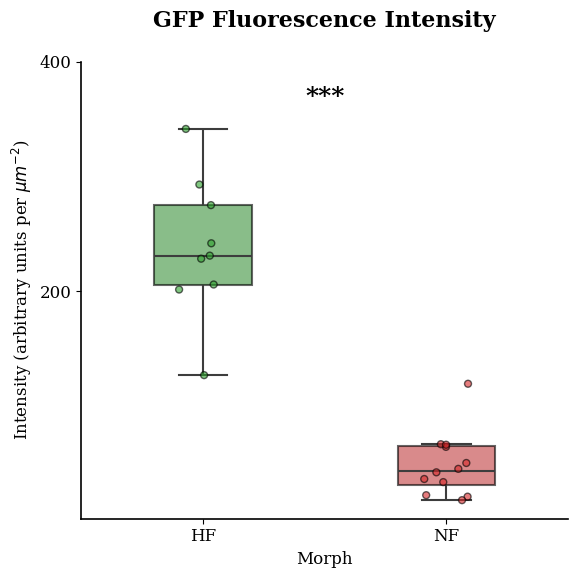

In [39]:
plt.figure(figsize=global_fig_size)

# Boxplot
sns.boxplot(data=df_gfp, x='Variant', y='Intensity_per_µm2',
            palette=variant_colors, width=global_box_width,
            showfliers=False, linewidth=1.5, hue='Variant', legend=False,
            boxprops={'edgecolor': 'black', 'alpha': global_alpha}) # Apply global_alpha here

# Stripplot
sns.stripplot(data=df_gfp, x='Variant', y='Intensity_per_µm2', hue='Variant',
              palette=variant_colors, size=global_marker_size,
              jitter=global_jitter, alpha=global_alpha, zorder=5,
              edgecolor=global_jitter_edgecolor, linewidth=global_jitter_linewidth) # Apply jitter outline settings

# Significance marker
if p_val < 0.05:
    plt.text(0.5, df_gfp['Intensity_per_µm2'].max() * 1.05,
             "***", ha='center', va='bottom',
             fontsize=global_asterisk_size, fontweight=global_asterisk_weight)

plt.title("GFP Fluorescence Intensity")
plt.ylabel("Intensity (arbitrary units per $\mu m^{-2}$)")
plt.xlabel("Morph")
plt.legend([], [], frameon=False)
sns.despine()

plt.locator_params(axis='y', nbins=global_y_nbins)
plt.ylim(top=400)

plt.tight_layout()
plt.savefig('GFP_Intensity.svg', dpi=600, format='svg')
plt.show()

# Block 6: Library Versions
Run this to track your environment configuration.

In [40]:
import scipy
print(f"pandas: {pd.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")

pandas: 2.2.2
scipy: 1.16.3
seaborn: 0.13.2
matplotlib: 3.10.0
